In [129]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [130]:
import sys
sys.path.append('/content/drive/MyDrive/ConceptualizingConceptDrift')

In [131]:
!pip install xplique wordcloud

In [132]:
from datasets import load_dataset
from transformers import AutoTokenizer

import torch
import numpy as np
import random
import string
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from collections import Counter
from IPython.core.display import display, HTML
from sklearn.model_selection import train_test_split

from experiment_helpers.helper_function import *
from experiment_helpers.driftLocalizer import Localizer
from text_helpers.CraftText import (
    CraftText, CraftTextCombined, full_text_activations,
    top_sentences, occlusion_concepts_text, occlusion_global_keywords
)
from text_helpers.CustomBertModel import CustomBertForSequenceClassification

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
from nltk.corpus import stopwords

np.random.seed(2)
random.seed(42)

device = 'cuda'
patch_mode = "window"

ignore_list = stopwords.words('english') + list(string.punctuation) + ["'s", "n't", "'re", "'ve", "'ll", "'d", "'m"]

checkpoint_name = "fabriceyhc/bert-base-uncased-yahoo_answers_topics"
model = CustomBertForSequenceClassification.from_pretrained(checkpoint_name, num_labels=10)
model = model.eval().to(device)
tokenizer = AutoTokenizer.from_pretrained(checkpoint_name)

yahoo = load_dataset("community-datasets/yahoo_answers_topics", split="test")

all_texts = [" ".join(x for x in (t, q, a) if x).replace("\\n", " ")
             for t, q, a in zip(yahoo["question_title"], yahoo["question_content"], yahoo["best_answer"])]
all_labels = np.array(yahoo["topic"])

# six topics. two before drift, two after drift, two in both
idd_class_ids = [5, 4, 2, 7, 1, 9]

subset_mask = np.isin(all_labels, idd_class_ids)
texts = [t for t, m in zip(all_texts, subset_mask) if m]
labels = all_labels[subset_mask]

sample_ids = np.random.choice(len(texts), 500, False)
sample_texts = [texts[i] for i in sample_ids]

label_map = {
    5: 0,   # sports                 -> BD
    4: 0,   # computers & internet   -> BD
    2: 1,   # health                 -> AD
    7: 1,   # entertainment & music  -> AD
    1: 2,   # science & mathematics  -> Both
    9: 2,   # politics & government  -> Both
}

labels_mapped = np.array([label_map[class_id] for class_id in labels])
drift_labels = labels_mapped[sample_ids]

label_2_idx = np.where(drift_labels == 2)[0]
y_mixed = drift_labels.copy()
y_mixed[label_2_idx] = np.random.choice([0, 1], size=len(label_2_idx))

sample_labels = y_mixed

patch_act = full_text_activations(sample_texts, model, tokenizer, device=device)
train_labels = sample_labels

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [133]:
bd_indices = np.where(sample_labels != 1)[0]
ad_indices = np.where(sample_labels != 0)[0]

In [134]:
bd_texts = [sample_texts[i] for i in bd_indices]
bd_labels = [sample_labels[i] for i in bd_indices]
ad_texts = [sample_texts[i] for i in ad_indices]
ad_labels = [sample_labels[i] for i in ad_indices]

bd_fit = CraftText(model_wrapper=model, tokenizer=tokenizer, num_concepts=10,
                    patch_mode=patch_mode, win_size=15, stride=10, device=device)
print("Fitting Unsupervised Craft....")
bd_crops, bd_crops_u, bd_w = bd_fit.fit(bd_texts, bd_labels)

ad_fit = CraftText(model_wrapper=model, tokenizer=tokenizer, num_concepts=10,
                    patch_mode=patch_mode, win_size=15, stride=10, device=device)
print("Fitting Unsupervised Craft....")
ad_crops, ad_crops_u, ad_w = ad_fit.fit(ad_texts, ad_labels)

drift_basis = np.vstack([bd_w, ad_w])

drift_craft = CraftTextCombined(model_wrapper=model, tokenizer=tokenizer, basis=drift_basis,
                                 patch_mode=patch_mode, win_size=15, stride=10, device=device)
print("Fitting Craft....")
drift_craft.transform_all(sample_texts, sample_labels)

Fitting Unsupervised Craft....
Fitting Unsupervised Craft....
Fitting Craft....


/usr/local/lib/python3.13/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


array([[2.61907466e-02, 1.09105761e-28, 9.31563914e-01, ...,
        7.25223077e-03, 4.43551664e-32, 8.27490166e-02],
       [1.40129846e-45, 3.34596795e-09, 1.05660838e-31, ...,
        9.19344968e-24, 9.97080202e-18, 4.93802756e-01],
       [7.86371995e-03, 3.57200909e-15, 6.07947588e-01, ...,
        1.02394015e-01, 1.73823658e-08, 2.86662214e-08],
       ...,
       [6.55874465e-30, 4.97891396e-01, 2.85808822e-28, ...,
        6.41864604e-24, 1.91043299e-02, 1.91718019e-09],
       [6.58511935e-24, 1.20799780e+00, 7.10567328e-05, ...,
        1.93083358e-20, 1.36086449e-03, 2.46846712e-38],
       [1.50034692e-22, 1.31046808e+00, 8.88689647e-06, ...,
        2.04575476e-18, 2.72966397e-04, 5.17471394e-34]], dtype=float32)

In [135]:
X_clean = patch_act
y_clean = sample_labels

X_train_clean, X_test_clean, y_train, y_test, idx_train, idx_test = \
    train_test_split(X_clean, y_clean, np.arange(len(X_clean)), train_size=0.7, random_state=42)
test_texts = [sample_texts[i] for i in idx_test]

localizer = Localizer(min_samples_leaf=20)
localizer.fit(X_train_clean, y_train)


low threshold: 0.3 Mean:0.4657142857142857 High threshold:0.65, No. Leaves:20


Localizer(min_samples_leaf=20)

In [136]:
drift_imp = np.round(estimate_importance_l(localizer, drift_craft, drift_basis, X_train_clean), 3)

y_preds, _ = l_compute_predictions(localizer, X_test_clean)

image_drift_imp = [
    estimate_importance_helper_l(drift_craft, localizer, drift_basis, text_vec, class_of_interest=y_preds[i])
    for i, text_vec in enumerate(X_test_clean)
]

y_train_preds, _ = l_compute_predictions(localizer, X_train_clean)

image_drift_imp_train = [
    estimate_importance_helper_l(drift_craft, localizer, drift_basis, text_vec, class_of_interest=y_train_preds[i])
    for i, text_vec in enumerate(X_train_clean)
]


/usr/local/lib/python3.13/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklea

In [137]:
print(image_drift_imp[0])
print(accuracy_score(y_preds, y_test))

[0.00063939 0.         0.20537695 0.         0.         0.
 0.         0.         0.00409696 0.         0.01392235 0.
 0.         0.         0.00667327 0.         0.42433992 0.
 0.         0.        ]
0.78


In [138]:
dist_dict = concept_counter(image_drift_imp_train, y_train_preds)
bd_dist = dist_dict[0]
ad_dist = dist_dict[1]
print(dist_dict)

{0: {np.int64(2): 0.2774869109947644, np.int64(9): 0.07329842931937172, np.int64(7): 0.015706806282722512, np.int64(1): 0.3403141361256545, np.int64(4): 0.07329842931937172, np.int64(8): 0.05235602094240838, np.int64(5): 0.020942408376963352, np.int64(14): 0.010471204188481676, np.int64(17): 0.005235602094240838, np.int64(3): 0.010471204188481676, np.int64(6): 0.031413612565445025, np.int64(13): 0.010471204188481676, np.int64(16): 0.05235602094240838, np.int64(18): 0.010471204188481676, np.int64(12): 0.005235602094240838, np.int64(11): 0.010471204188481676}, 1: {np.int64(14): 0.2830188679245283, np.int64(12): 0.3333333333333333, np.int64(4): 0.10062893081761007, np.int64(11): 0.050314465408805034, np.int64(16): 0.1320754716981132, np.int64(19): 0.031446540880503145, np.int64(7): 0.012578616352201259, np.int64(13): 0.018867924528301886, np.int64(9): 0.006289308176100629, np.int64(8): 0.025157232704402517, np.int64(3): 0.006289308176100629}}


In [139]:
print(local_imp_concepts_probability(dist_dict, image_drift_imp, 1, y_test))
print(local_one_imp_concept_globally_l(drift_craft, image_drift_imp, y_test))
print(local_imp_concepts_globally_l(drift_craft, image_drift_imp, 1, y_test))
print(local_imp_concepts_globally_l(drift_craft, image_drift_imp, 2, y_test))
print(local_imp_concepts_globally_l(drift_craft, image_drift_imp, 3, y_test))
print(global_imp_concepts_locally_l(drift_craft, image_drift_imp, 1, y_test))
print(global_imp_concepts_locally_l(drift_craft, image_drift_imp, 2, y_test))
print(global_imp_concepts_locally_l(drift_craft, image_drift_imp, 3, y_test))

0.8
0.8333333333333334
0.82
0.6933333333333334
0.6666666666666666
0.6
0.76
0.7866666666666666


In [140]:
print(local_imp_concepts_probability(dist_dict, image_drift_imp, 1, y_preds))
print(local_one_imp_concept_globally_l(drift_craft, image_drift_imp, y_preds))
print(local_imp_concepts_globally_l(drift_craft, image_drift_imp, 1, y_preds))
print(local_imp_concepts_globally_l(drift_craft, image_drift_imp, 2, y_preds))
print(local_imp_concepts_globally_l(drift_craft, image_drift_imp, 3, y_preds))
print(global_imp_concepts_locally_l(drift_craft, image_drift_imp, 1, y_preds))
print(global_imp_concepts_locally_l(drift_craft, image_drift_imp, 2, y_preds))
print(global_imp_concepts_locally_l(drift_craft, image_drift_imp, 3, y_preds))

0.8466666666666667
0.8533333333333334
0.88
0.78
0.7266666666666667
0.6066666666666667
0.7666666666666667
0.8333333333333334


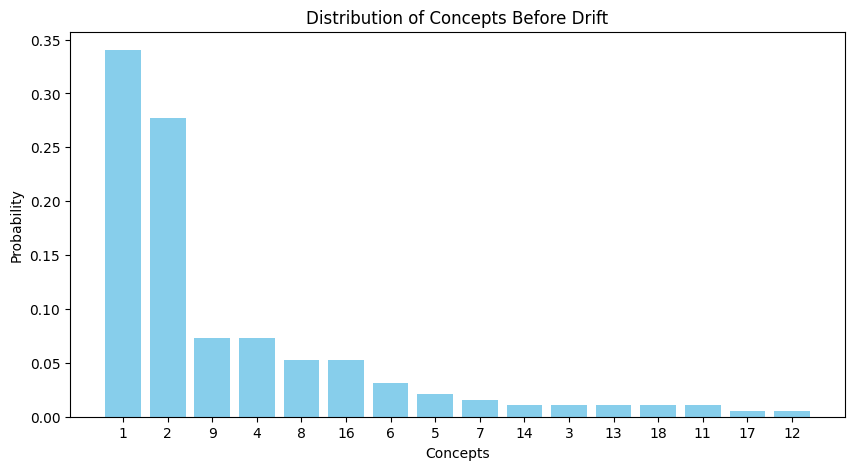

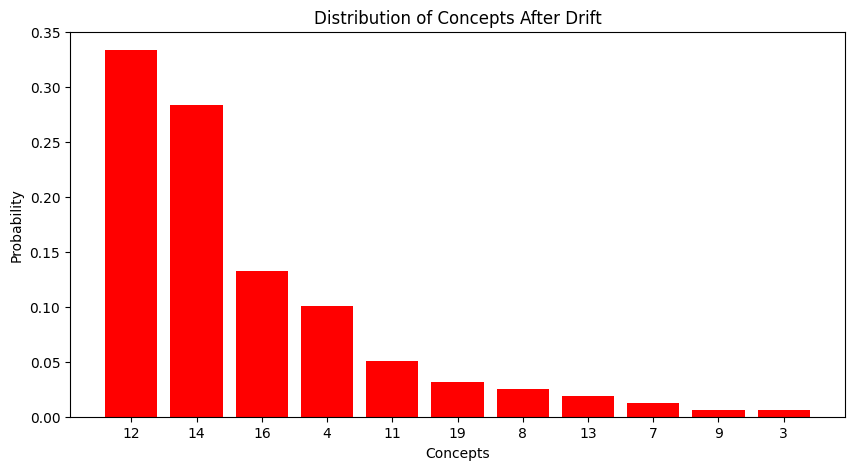

In [141]:
from collections import Counter
import matplotlib.pyplot as plt

sample_local_imp = np.array(image_drift_imp_train)
before_drift_counter = Counter()
after_drift_counter = Counter()

for drift_label in np.unique(y_train):
    drift_fil = y_train_preds == drift_label
    for imp in sample_local_imp[drift_fil]:
        local_imp_sort = np.argsort(imp)[::-1][0]
        if drift_label == 0:
            before_drift_counter[local_imp_sort] += 1
        elif drift_label == 1:
            after_drift_counter[local_imp_sort] += 1

total_before = sum(before_drift_counter.values())
total_after = sum(after_drift_counter.values())

before_drift_dist = {c: n / total_before for c, n in before_drift_counter.items()}
after_drift_dist = {c: n / total_after for c, n in after_drift_counter.items()}

sorted_before = sorted(before_drift_dist.items(), key=lambda x: x[1], reverse=True)
sorted_after = sorted(after_drift_dist.items(), key=lambda x: x[1], reverse=True)

def plot_distribution(dist, title, color):
    concepts, probs = zip(*dist)
    plt.figure(figsize=(10, 5))
    plt.bar([str(c) for c in concepts], probs, color=color)
    plt.xlabel('Concepts')
    plt.ylabel('Probability')
    plt.title(title)
    plt.show()

plot_distribution(sorted_before, "Distribution of Concepts Before Drift", "skyblue")
plot_distribution(sorted_after, "Distribution of Concepts After Drift", "red")

In [168]:
idx = 30

top5_concepts = list(set([c for c, _ in sorted_before[:5]] + [c for c, _ in sorted_after[:5]]))
local_top5 = list(np.argsort(image_drift_imp[idx])[::-1][:5])

In [169]:
all_relevant_concepts = sorted(set(top5_concepts) | set(local_top5))
color_map = cm.get_cmap('tab20')
colors_rgba = {c: f"rgba({int(color_map(i)[0]*255)},{int(color_map(i)[1]*255)},{int(color_map(i)[2]*255)}," for i, c in enumerate(all_relevant_concepts)}
colors_hex = {c: color_map(i) for i, c in enumerate(all_relevant_concepts)}

/tmp/ipykernel_1007/972296876.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = cm.get_cmap('tab20')


In [170]:
print(f"text: {test_texts[idx]}")
print(f"label: {y_test[idx]}  pred: {y_preds[idx]}")

local_imp = image_drift_imp[idx]
top_concept = np.argsort(local_imp)[::-1][0]
print(f"top concept: {top_concept}")

text: who else is happy about steelers winning the superbowl? I WAS AT THE GAMES IN DETROIT AND IT WAS WORTH EVERY PENNY I SPENT...GOOD GAME, IT WAS AWSOME,I WAS HAPPY AND GLAD THE STEELERS WON!   DID I SAY IT WAS AWSOME! (DOPEIE)
label: 0  pred: 0
top concept: 2


/usr/local/lib/python3.13/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklea

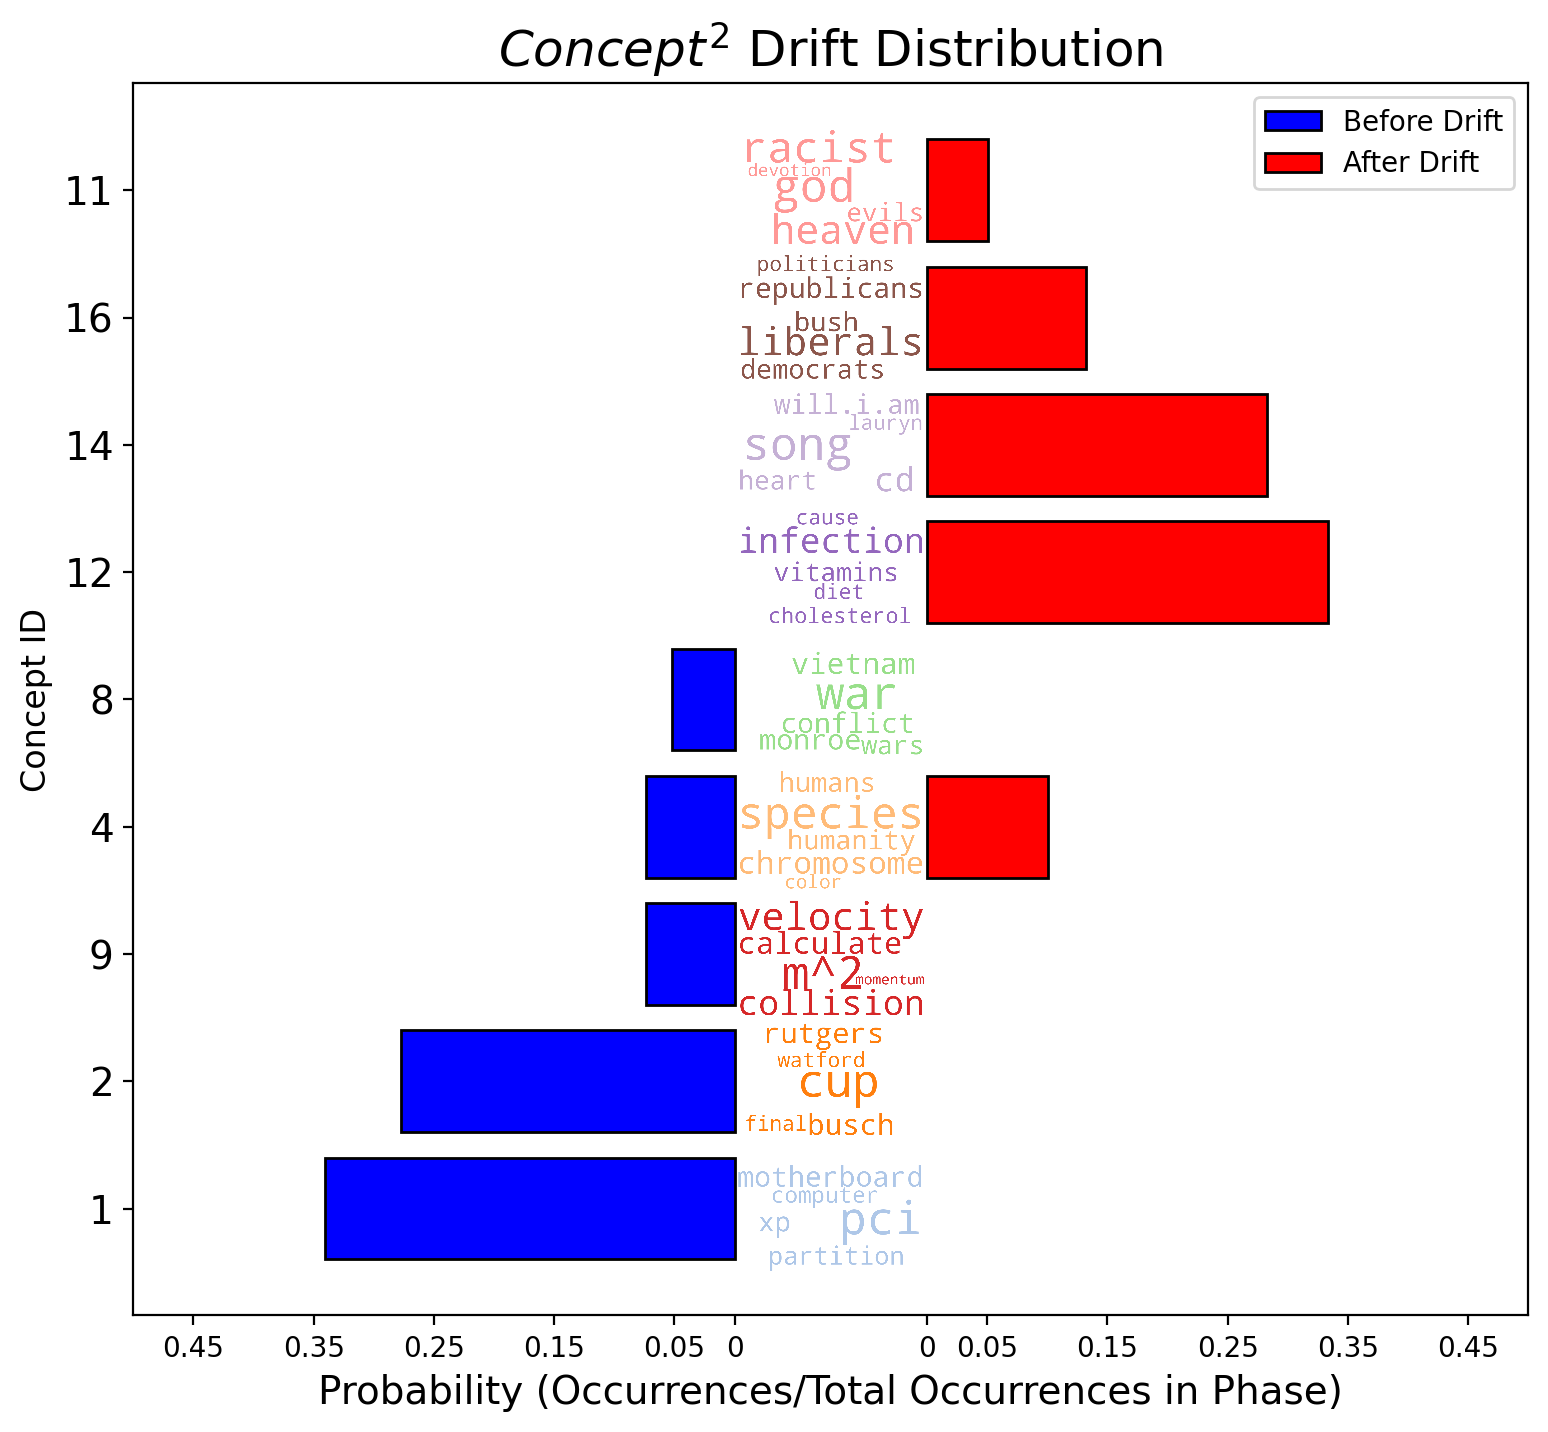

In [171]:
from wordcloud import WordCloud
from matplotlib.offsetbox import OffsetImage, AnnotationBbox


def concept_wordcloud(concept, color):
    keyword_freqs = occlusion_global_keywords(
        concept, drift_craft.embedding, drift_craft.crops, drift_basis,
        model, tokenizer, ignore_list, top_n_patches=20, top_n_words=5, device=device
    )
    if len(keyword_freqs) == 0:
        keyword_freqs = {"n/a": 1}
    hex_color = f"#{int(color[0]*255):02x}{int(color[1]*255):02x}{int(color[2]*255):02x}"
    return WordCloud(width=900, height=600, background_color="white",
                     min_font_size=28, max_font_size=220, prefer_horizontal=1.0,
                     color_func=lambda *args, **kwargs: hex_color).generate_from_frequencies(keyword_freqs)


def get_colored_wordcloud_image(concept, color):
    return OffsetImage(np.array(concept_wordcloud(concept, color)), zoom=0.075)


def plot_distribution_with_wordclouds(bd_dist, ad_dist):
    ad_concepts, ad_probs = zip(*ad_dist[:5])
    bd_concepts, bd_probs = zip(*bd_dist[:5])
    ad_probs = np.array(ad_probs)
    bd_probs = np.array(bd_probs)
    ad_concepts_str = np.array(ad_concepts).astype(str)
    bd_concepts_str = np.array(bd_concepts).astype(str)

    all_concepts_raw = list(bd_concepts) + list(ad_concepts)
    all_concepts_str = np.append(bd_concepts_str, ad_concepts_str)

    fig, ax = plt.subplots(figsize=(9, 8), dpi=200)
    bar_offset = 0.08

    ax.barh(bd_concepts_str, -bd_probs, color='blue', edgecolor="black", label='Before Drift', left=-bar_offset)
    ax.barh(ad_concepts_str, ad_probs, color='red', edgecolor="black", label='After Drift', left=bar_offset)

    for concept_raw, concept_str in zip(all_concepts_raw, all_concepts_str):
        image = get_colored_wordcloud_image(int(concept_raw), colors_hex[concept_raw])
        ab = AnnotationBbox(image, (0, concept_str), frameon=False)
        ax.add_artist(ab)

    ax.set_yticks(np.unique(all_concepts_str))
    ax.set_yticklabels([f"{c}" for c in np.unique(all_concepts_str)], fontsize=14)

    tick_values = [0.45, 0.35, 0.25, 0.15, 0.05]
    tick_positions = [-(v + bar_offset) for v in tick_values] + [-bar_offset, bar_offset] + [v + bar_offset for v in tick_values[::-1]]
    tick_labels = ["0.45", "0.35", "0.25", "0.15", "0.05", "0", "0", "0.05", "0.15", "0.25", "0.35", "0.45"]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)
    ax.set_xlim(-(0.5 + bar_offset), 0.5 + bar_offset)

    ax.set_xlabel("Probability (Occurrences/Total Occurrences in Phase)", fontsize=14)
    ax.set_ylabel("Concept ID", fontsize=12)
    ax.set_title("$Concept^2$ Drift Distribution", fontsize=18)
    ax.legend()
    plt.show()


plot_distribution_with_wordclouds(sorted_before, sorted_after)

In [172]:
words, importances = occlusion_concepts_text(
    test_texts[idx].lower(), model, tokenizer, drift_basis,
    concept_ids=local_top5, ignore_words=ignore_list, device=device
)

phi_all = np.array(importances)
global_max = np.max(np.abs(phi_all)) + 1e-5
phi_all_norm = phi_all / global_max
phi_display = np.sign(phi_all_norm) * np.sqrt(np.clip(np.abs(phi_all_norm), 0, 1))

phi_html = []
for i in range(len(words)):
    k = np.argmax(phi_display[:, i])
    val = phi_display[k, i]
    if val > 0.25:
        phi_html.append(f'<span style="background-color: {colors_rgba[local_top5[k]]}{val:.2f}); padding: 1px 5px;">{words[i]}</span>')
    else:
        phi_html.append(f'<span style="padding: 1px 5px;">{words[i]}</span>')
display(HTML("<div style='display: flex; width: 500px; flex-wrap: wrap'>" + " ".join(phi_html) + "</div>"))

In [173]:
words_global, importances_global = occlusion_concepts_text(
    test_texts[idx].lower(), model, tokenizer, drift_basis,
    concept_ids=top5_concepts, ignore_words=ignore_list, device=device
)
phi_global = np.array(importances_global)
phi_global_norm = phi_global / (np.max(np.abs(phi_global)) + 1e-5)
phi_global_display = np.sign(phi_global_norm) * np.sqrt(np.clip(np.abs(phi_global_norm), 0, 1))

phi_html_global = []
for i in range(len(words_global)):
    k = np.argmax(phi_global_display[:, i])
    val = phi_global_display[k, i]
    if val > 0.25:
        phi_html_global.append(f'<span style="background-color: {colors_rgba[top5_concepts[k]]}{val:.2f}); padding: 1px 5px;">{words_global[i]}</span>')
    else:
        phi_html_global.append(f'<span style="padding: 1px 5px;">{words_global[i]}</span>')
display(HTML("<div style='display: flex; width: 500px; flex-wrap: wrap'>" + " ".join(phi_html_global) + "</div>"))

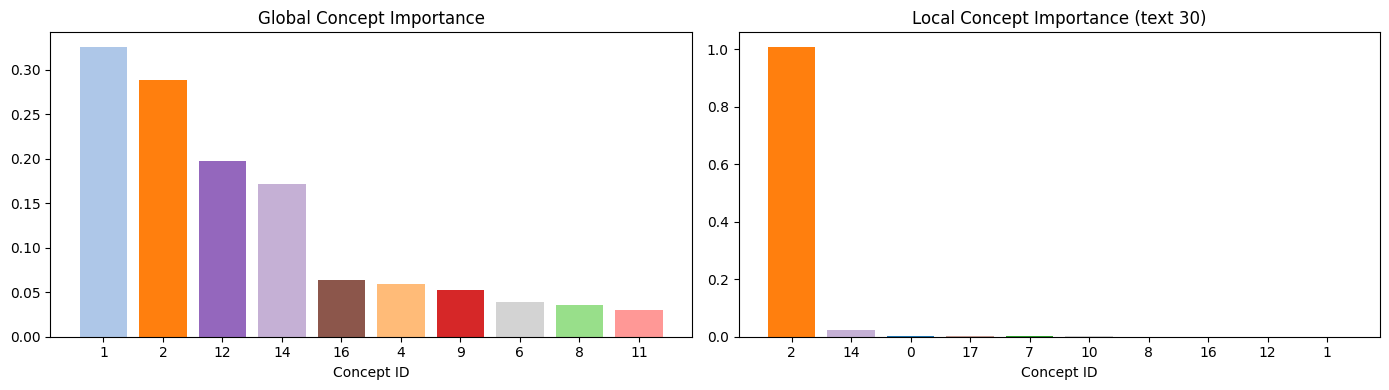

In [174]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

global_importance = np.maximum(drift_craft.sensitivities[0].importances, drift_craft.sensitivities[1].importances)
top_idx_g = np.argsort(global_importance)[::-1][:10]
bar_colors_g = [colors_hex[c] if c in colors_hex else "lightgray" for c in top_idx_g]
axes[0].bar([str(i) for i in top_idx_g], global_importance[top_idx_g], color=bar_colors_g)
axes[0].set_title("Global Concept Importance")
axes[0].set_xlabel("Concept ID")

local_importance = image_drift_imp[idx]
top_idx_l = np.argsort(local_importance)[::-1][:10]
bar_colors_l = [colors_hex[c] if c in colors_hex else "lightgray" for c in top_idx_l]
axes[1].bar([str(i) for i in top_idx_l], local_importance[top_idx_l], color=bar_colors_l)
axes[1].set_title(f"Local Concept Importance (text {idx})")
axes[1].set_xlabel("Concept ID")

plt.tight_layout()
plt.show()

/usr/local/lib/python3.13/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklea

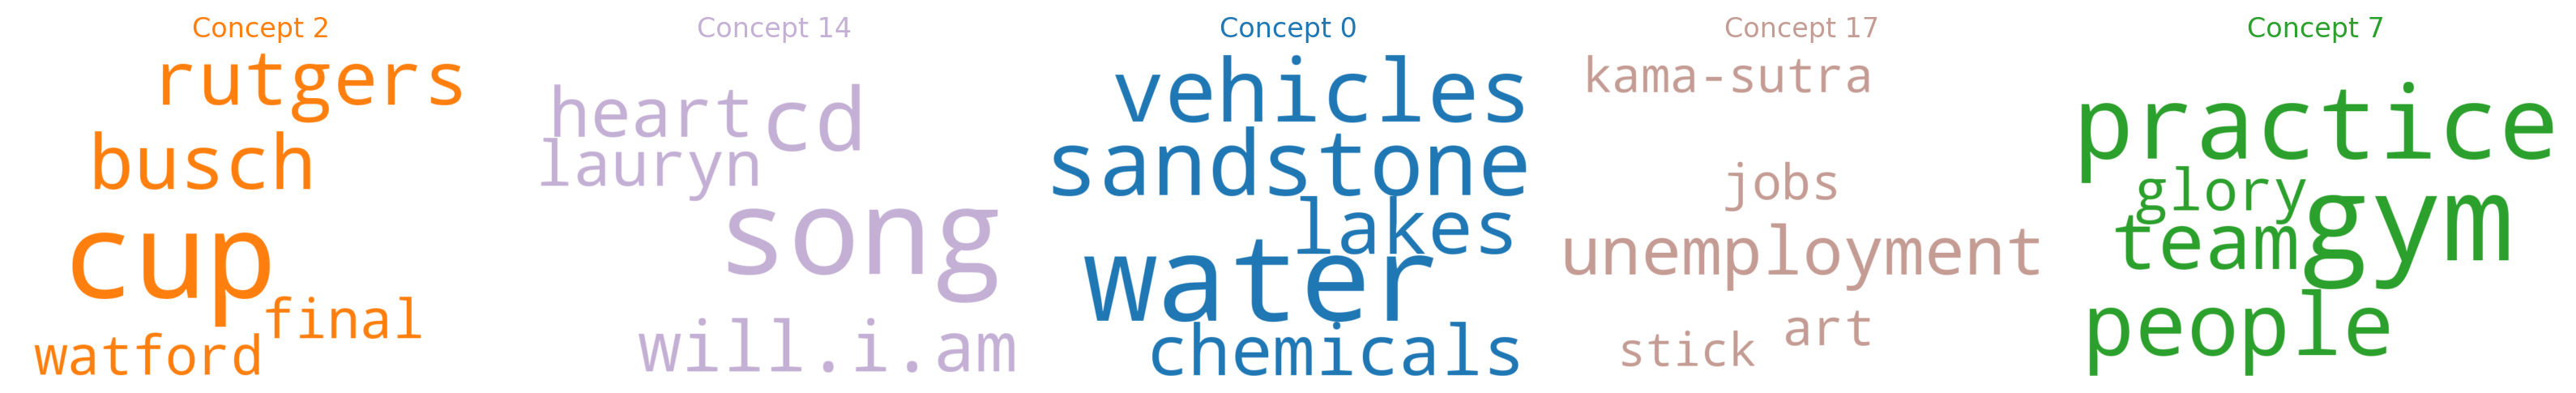

/usr/local/lib/python3.13/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklea

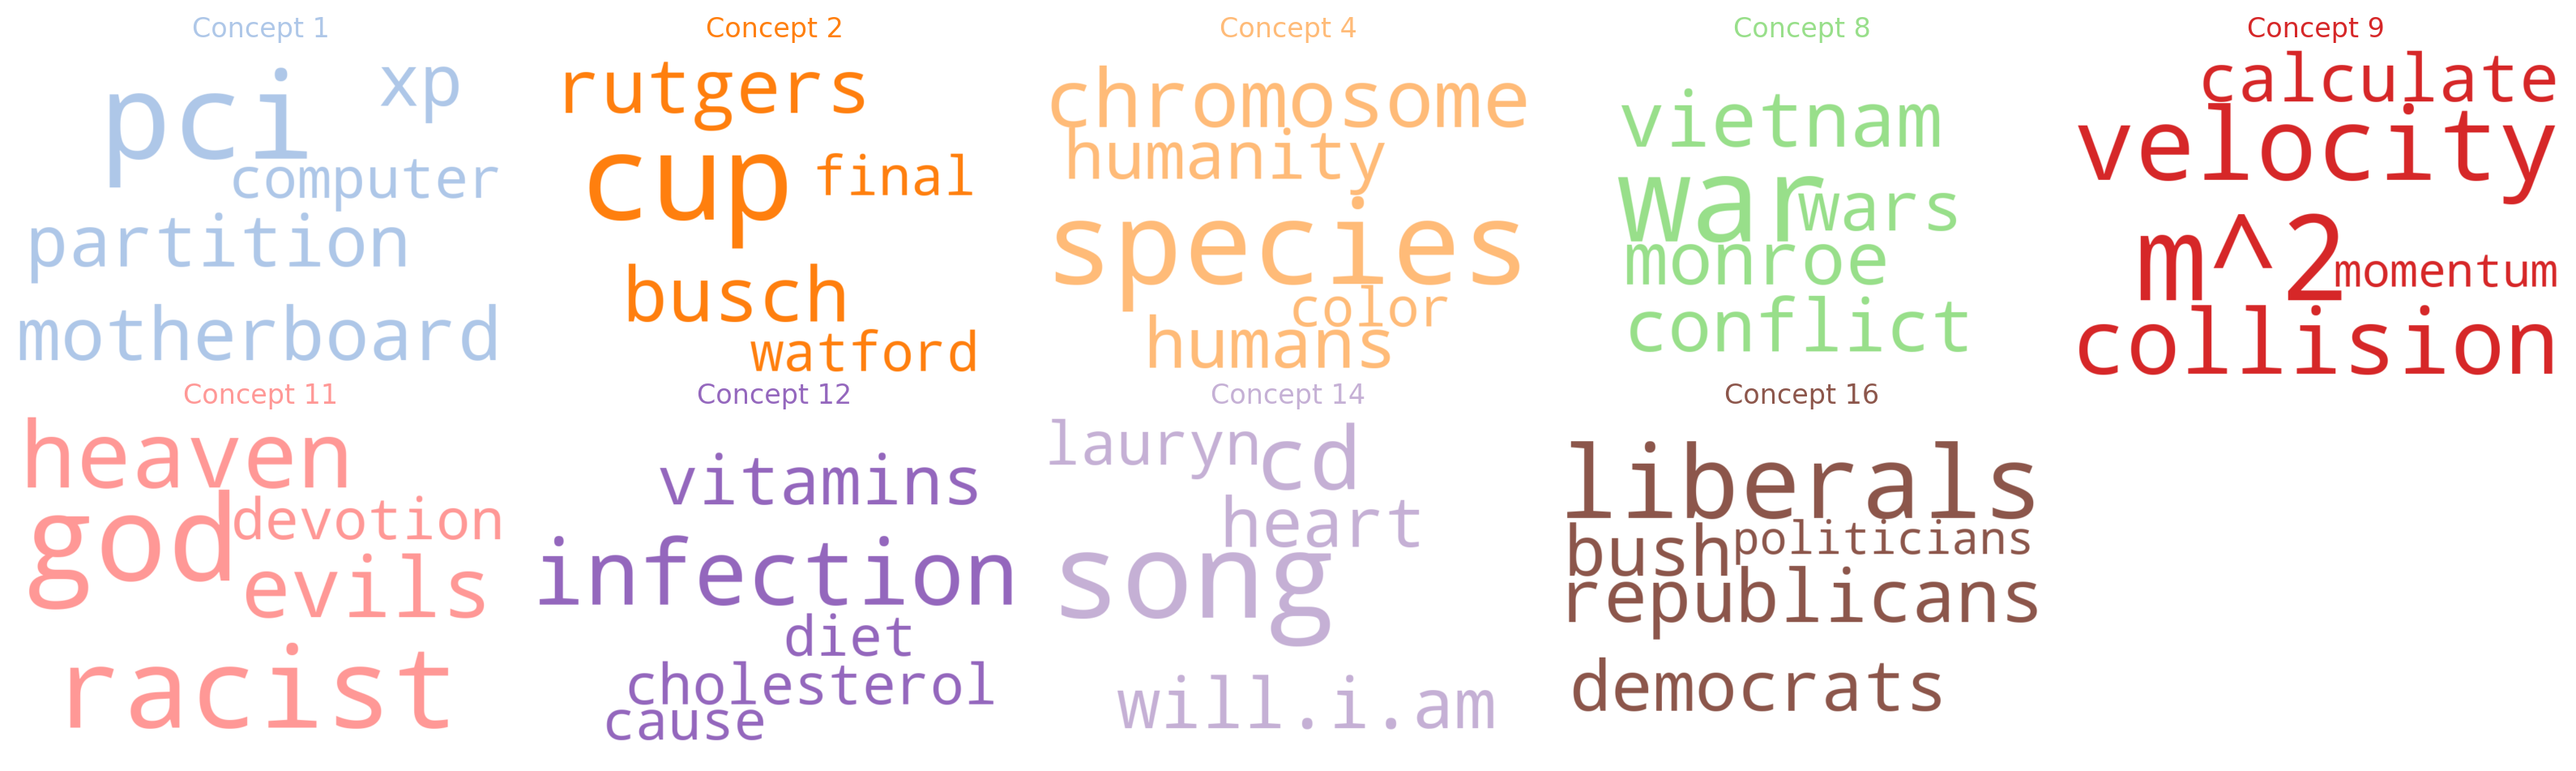

In [175]:
def plot_concept_wordclouds(concept_ids, per_row=5):
    n = len(concept_ids)
    rows = int(np.ceil(n / per_row))
    fig, axes = plt.subplots(rows, per_row, figsize=(3.2 * per_row, 2.4 * rows), dpi=200)
    axes = np.array(axes).reshape(-1)
    for ax, concept in zip(axes, concept_ids):
        ax.imshow(np.array(concept_wordcloud(int(concept), colors_hex[concept])), interpolation="bilinear")
        ax.set_title(f"Concept {concept}", fontsize=12, color=colors_hex[concept])
        ax.axis("off")
    for ax in axes[len(concept_ids):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


plot_concept_wordclouds(local_top5)
plot_concept_wordclouds(top5_concepts)
